# Feature importance: train tenure bins vs test (preprocessed data)

**Data:** `data/preprocessed/train/` and `data/preprocessed/test/` (from `preprocess_data.py`).

**Bins (train only):** `pd.qcut` on **`sub_days`** (days since global min `subscription_start_date` **on train**), equal N per bin. **Test users are not split into bins** (~7k rows); they get the same engineered features and **`sub_days` using the same `t0` as train** so timelines align.

**Why not per-bin models:** Early stopping on ~15k rows often collapsed to **one tree**, so `PredictionValuesChange` was unstable.

**Why OOF SHAP (not fit-on-all-then-SHAP on train):** Training on **100%** of train and computing SHAP on the **same** rows inflates importance for **noisy** features (memorization). We use **stratified K-fold**: each fold trains on **K−1** folds and computes **SHAP only on the held-out fold** (labels unused for that user during fit). Stitched OOF SHAP gives **unbiased** mean |SHAP| per tenure bin. **Test:** We report **mean |SHAP|** averaged over **K** fold models (each trained on ~80% of train). That is a **pragmatic** attribution blend (not a single model’s exact SHAP decomposition), but it avoids one **full-train** explainer dominating the story.

**“Degraded” features:** Features with **high** mean |SHAP| in **early** tenure bins (bins 1–2, roughly Aug–Sep cohorts) but **much lower** in **late** bins (5–6) *and* **low** on test suggest the model may lean on signals that **weakened over time** and may **not** match the test-era cohort—worth monitoring or down-weighting.

**Validation proxy:** We pick the **train `bin_id`** whose **`sub_days` distribution** is closest to test (**Wasserstein-1** distance). Use that slice as a **pseudo-validation** era; still use proper CV for leaderboard.

**Correlations:** Numeric-only **Pearson** with `churn_binary` per train bin (supplement to SHAP; categoricals omitted).

**CatBoost vs correlation:** CatBoost + SHAP captures **nonlinear** use of high-cardinality categoricals; per-bin correlation only covers **numeric** columns linearly.

**Cache:** After the first full run, engineered tables are written to `data/preprocessed/cache/train_users_engineered.csv` and `test_users_engineered.csv`. Next time, set **`USE_ENGINEERED_CACHE = True`** in the load cell and **skip** the heavy merge/generation cells (they no-op when cache is loaded).


In [35]:
from __future__ import annotations

import re
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dateutil.parser import isoparse
from IPython.display import display
from scipy.stats import wasserstein_distance

try:
    from sklearn.model_selection import StratifiedKFold, train_test_split
except ImportError:
    train_test_split = None
    StratifiedKFold = None

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

PROJECT_ROOT = Path(".").resolve()
PRE = PROJECT_ROOT / "data" / "preprocessed"
TRAIN_DIR = PRE / "train"
TEST_DIR = PRE / "test"

TRAIN_USERS = TRAIN_DIR / "train_users.csv"
TRAIN_PROPS = TRAIN_DIR / "train_users_properties.csv"
TRAIN_PURCH = TRAIN_DIR / "train_users_purchases.csv"
TRAIN_TX = TRAIN_DIR / "train_users_transaction_attempts.csv"
TRAIN_QUIZ = TRAIN_DIR / "train_users_quizzes.csv"
TRAIN_GEN = TRAIN_DIR / "train_users_generations.csv"

TEST_USERS = TEST_DIR / "test_users.csv"
TEST_PROPS = TEST_DIR / "test_users_properties.csv"
TEST_PURCH = TEST_DIR / "test_users_purchases.csv"
TEST_TX = TEST_DIR / "test_users_transaction_attempts.csv"
TEST_QUIZ = TEST_DIR / "test_users_quizzes.csv"
TEST_GEN = TEST_DIR / "test_users_generations.csv"

N_BINS = 6
SKIP_QUIZ = "skipped_quiz"
RARE_MIN_COUNT = 80
CHUNK = 300_000
EARLY_BINS = (1, 2)
LATE_BINS = (5, 6)
RNG = 42
N_SPLITS = 5
INNER_VAL_FRAC = 0.1


def read_csv_drop_index(path: Path, **kwargs) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False, **kwargs)
    c0 = df.columns[0]
    if str(c0).startswith("Unnamed") or str(c0).lower() == "skipped":
        df = df.drop(columns=c0)
    return df


def parse_subscription_ts(s: str) -> datetime:
    m = re.match(r"(\d{4})-(\d{2})-(\d{2})[ T](\d{2}):(\d{2}):(\d{2})", str(s))
    if not m:
        raise ValueError(s)
    y, mo, d, h, mi, se = map(int, m.groups())
    return datetime(y, mo, d, h, mi, se)


CACHE_DIR = PRE / "cache"
ENGINEERED_TRAIN_CSV = CACHE_DIR / "train_users_engineered.csv"
ENGINEERED_TEST_CSV = CACHE_DIR / "test_users_engineered.csv"
_ENGINEERED_FROM_CACHE = False


In [36]:
# --- Optional: load engineered train/test tables (skips merges + chunked generations)
USE_ENGINEERED_CACHE = False  # set True after you have saved CSVs once
if USE_ENGINEERED_CACHE and ENGINEERED_TRAIN_CSV.is_file() and ENGINEERED_TEST_CSV.is_file():
    base_train = pd.read_csv(ENGINEERED_TRAIN_CSV, low_memory=False)
    base_test = pd.read_csv(ENGINEERED_TEST_CSV, low_memory=False)
    base_train["sub_start"] = base_train["subscription_start_date"].map(parse_subscription_ts)
    base_test["sub_start"] = base_test["subscription_start_date"].map(parse_subscription_ts)
    t0 = base_train["sub_start"].min()
    if "bin_id" in base_train.columns:
        base_train["bin_id"] = pd.to_numeric(base_train["bin_id"], errors="coerce").astype("Int64")
    _ENGINEERED_FROM_CACHE = True
    print("Loaded:", ENGINEERED_TRAIN_CSV, "|", ENGINEERED_TEST_CSV)
else:
    print("Full pipeline will run (merges + generations). Set USE_ENGINEERED_CACHE=True to skip after cache exists.")


Full pipeline will run (merges + generations). Set USE_ENGINEERED_CACHE=True to skip after cache exists.


In [37]:
# --- Train base: churn + sub_days + equal-N bins (qcut on train only)
if not _ENGINEERED_FROM_CACHE:
    users = read_csv_drop_index(TRAIN_USERS)
    props = read_csv_drop_index(TRAIN_PROPS)
    base_train = users.merge(props, on="user_id", how="left", validate="one_to_one")
    base_train["churn_binary"] = base_train["churn_status"].isin(["vol_churn", "invol_churn"]).astype(int)
    base_train["sub_start"] = base_train["subscription_start_date"].map(parse_subscription_ts)
    t0 = base_train["sub_start"].min()
    base_train["sub_days"] = base_train["sub_start"].apply(lambda t: (t - t0).total_seconds() / 86400.0)

    base_train["period_q"], _ = pd.qcut(
        base_train["sub_days"],
        q=N_BINS,
        duplicates="drop",
        retbins=True,
    )
    base_train["bin_id"] = base_train["period_q"].cat.codes + 1
    print("train bin_id counts:\n", base_train["bin_id"].value_counts().sort_index())


train bin_id counts:
 bin_id
1    15000
2    15000
3    15000
4    15000
5    15000
6    15000
Name: count, dtype: int64


In [38]:
# --- Test base: same sub_days origin as train (no churn, no bins)
if not _ENGINEERED_FROM_CACHE:
    test_u = read_csv_drop_index(TEST_USERS)
    test_p = read_csv_drop_index(TEST_PROPS)
    base_test = test_u.merge(test_p, on="user_id", how="left", validate="one_to_one")
    base_test["sub_start"] = base_test["subscription_start_date"].map(parse_subscription_ts)
    base_test["sub_days"] = base_test["sub_start"].apply(lambda t: (t - t0).total_seconds() / 86400.0)
    base_test["bin_id"] = np.nan
    print("test rows:", len(base_test))
    print("test sub_days median:", base_test["sub_days"].median())


test rows: 7000
test sub_days median: 82.40206018518518


In [39]:
# --- Quizzes (train + test)


def merge_quiz(base: pd.DataFrame, quiz_path: Path) -> pd.DataFrame:
    quiz_raw = read_csv_drop_index(quiz_path)
    quiz_cols = [c for c in quiz_raw.columns if c not in ("user_id",) and not str(c).startswith("Unnamed")]
    q = quiz_raw[["user_id"] + quiz_cols].copy()
    for c in quiz_cols:
        if q[c].dtype == object or str(q[c].dtype) == "string":
            q[c] = q[c].fillna(SKIP_QUIZ).astype(str)
            q.loc[q[c].str.strip() == "", c] = SKIP_QUIZ
        else:
            q[c] = q[c].fillna(-1)
    q = q.rename(columns={"source": "quiz_source"})
    out = base.merge(q, on="user_id", how="left")
    for c in quiz_cols:
        col = "quiz_source" if c == "source" else c
        if col not in out.columns:
            continue
        if out[col].dtype == object or str(out[col].dtype) == "string":
            out[col] = out[col].fillna(SKIP_QUIZ).astype(str)
        else:
            out[col] = out[col].fillna(-1)
    out["has_quiz_row"] = out["user_id"].isin(set(quiz_raw["user_id"])).astype(int)
    return out


if not _ENGINEERED_FROM_CACHE:
    base_train = merge_quiz(base_train, TRAIN_QUIZ)
    base_test = merge_quiz(base_test, TEST_QUIZ)
    print("train has_quiz_row mean:", base_train["has_quiz_row"].mean(), "| test:", base_test["has_quiz_row"].mean())


train has_quiz_row mean: 1.0 | test: 1.0


In [40]:
# --- Purchases + transactions (train + test)


def merge_purchase_tx(base: pd.DataFrame, purch_path: Path, tx_path: Path) -> pd.DataFrame:
    purch = read_csv_drop_index(purch_path)
    purch["purchase_time"] = purch["purchase_time"].map(
        lambda x: isoparse(str(x)) if pd.notna(x) else pd.NaT
    )
    purch = purch.sort_values("purchase_time")
    first_p = purch.groupby("user_id", as_index=False).first()
    n_purch = purch.groupby("user_id").size().rename("n_purchases")
    trans = read_csv_drop_index(tx_path)
    fp = first_p.merge(trans, on="transaction_id", how="left")
    tx_cat = [
        "cvc_check",
        "card_country",
        "card_funding",
        "card_brand",
        "payment_method_type",
        "digital_wallet",
        "billing_address_country",
        "bank_country",
    ]
    tx_bool = ["is_3d_secure", "is_prepaid", "is_virtual", "is_business"]
    take = ["user_id", "purchase_type", "purchase_amount_dollars"] + [c for c in tx_cat + tx_bool if c in fp.columns]
    feat_p = fp[take].merge(n_purch, on="user_id", how="left")
    feat_p["n_purchases"] = feat_p["n_purchases"].fillna(0).astype(int)
    for c in tx_cat:
        if c in feat_p.columns:
            feat_p[c] = feat_p[c].fillna("missing").astype(str)
    for c in tx_bool:
        if c in feat_p.columns:
            feat_p[c] = feat_p[c].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(-1).astype(int)
    feat_p["purchase_type"] = feat_p["purchase_type"].fillna("missing").astype(str)
    feat_p["purchase_amount_dollars"] = feat_p["purchase_amount_dollars"].fillna(-1.0)
    out = base.merge(feat_p, on="user_id", how="left")
    for c in ["purchase_type", "purchase_amount_dollars", "n_purchases"] + tx_cat + tx_bool:
        if c not in out.columns:
            continue
        if c in tx_bool:
            out[c] = out[c].fillna(-1)
        elif c == "purchase_amount_dollars":
            out[c] = out[c].fillna(-1.0)
        elif c == "n_purchases":
            out[c] = out[c].fillna(0).astype(int)
        else:
            out[c] = out[c].fillna("missing").astype(str)
    return out


if not _ENGINEERED_FROM_CACHE:
    base_train = merge_purchase_tx(base_train, TRAIN_PURCH, TRAIN_TX)
    base_test = merge_purchase_tx(base_test, TEST_PURCH, TEST_TX)


In [41]:
# --- Generations aggregates (chunked; Python datetime only)


def days_from_subscription(created_list, sub_list):
    out = np.empty(len(created_list), dtype=np.float64)
    for i, (c, s) in enumerate(zip(created_list, sub_list)):
        if pd.isna(c) or s is None:
            out[i] = np.nan
            continue
        if getattr(c, "tzinfo", None):
            c = c.replace(tzinfo=None)
        if getattr(s, "tzinfo", None):
            s = s.replace(tzinfo=None)
        out[i] = (c - s).total_seconds() / 86400.0
    return out


def aggregate_generations(base: pd.DataFrame, gen_path: Path) -> pd.DataFrame:
    uid_index = pd.Index(base["user_id"].unique(), name="user_id")
    acc = {
        "tot": pd.Series(0.0, index=uid_index),
        "comp": pd.Series(0.0, index=uid_index),
        "nsfw": pd.Series(0.0, index=uid_index),
        "fail": pd.Series(0.0, index=uid_index),
        "canc": pd.Series(0.0, index=uid_index),
        "d0": pd.Series(0.0, index=uid_index),
        "d13": pd.Series(0.0, index=uid_index),
    }
    n_chunks = 0
    for ch in pd.read_csv(
        gen_path,
        chunksize=CHUNK,
        usecols=["user_id", "created_at", "status"],
        low_memory=False,
    ):
        n_chunks += 1
        ch = ch.merge(base[["user_id", "sub_start"]], on="user_id", how="inner")
        ch = ch.dropna(subset=["sub_start"])
        cr = [isoparse(str(x)) if pd.notna(x) else pd.NaT for x in ch["created_at"]]
        ch["created"] = cr
        ch = ch.dropna(subset=["created"])
        subs = ch["sub_start"].tolist()
        crl = ch["created"].tolist()
        ch["days_from_sub"] = days_from_subscription(crl, subs)
        ch = ch.dropna(subset=["days_from_sub"])
        st = ch["status"].astype(str)
        ch["__comp"] = (st == "completed").astype(int)
        ch["__nsfw"] = (st == "nsfw").astype(int)
        ch["__fail"] = (st == "failed").astype(int)
        ch["__canc"] = (st == "canceled").astype(int)
        ch["__d0"] = ((ch["days_from_sub"] >= 0) & (ch["days_from_sub"] < 1)).astype(int)
        ch["__d13"] = ((ch["days_from_sub"] >= 13) & (ch["days_from_sub"] < 14)).astype(int)
        ch["__n"] = 1
        g = ch.groupby("user_id")[
            ["__n", "__comp", "__nsfw", "__fail", "__canc", "__d0", "__d13"]
        ].sum()
        acc["tot"] = acc["tot"].add(g["__n"], fill_value=0)
        acc["comp"] = acc["comp"].add(g["__comp"], fill_value=0)
        acc["nsfw"] = acc["nsfw"].add(g["__nsfw"], fill_value=0)
        acc["fail"] = acc["fail"].add(g["__fail"], fill_value=0)
        acc["canc"] = acc["canc"].add(g["__canc"], fill_value=0)
        acc["d0"] = acc["d0"].add(g["__d0"], fill_value=0)
        acc["d13"] = acc["d13"].add(g["__d13"], fill_value=0)
        if n_chunks % 15 == 0:
            print("chunks", gen_path.name, n_chunks)
    out = base.copy()
    m = out["user_id"].map
    n_tot = m(acc["tot"]).fillna(0).to_numpy(dtype=np.float64)
    n_comp = m(acc["comp"]).fillna(0).to_numpy(dtype=np.float64)
    n_nsfw = m(acc["nsfw"]).fillna(0).to_numpy(dtype=np.float64)
    d0 = m(acc["d0"]).fillna(0).to_numpy()
    d13 = m(acc["d13"]).fillna(0).to_numpy()
    out["total_generations"] = n_tot
    # np.where evaluates both branches → 0/0 on n_tot==0 warns; use divide(..., where=...)
    ok = (n_tot > 0) & np.isfinite(n_tot)
    nsfw_rate = np.zeros_like(n_tot, dtype=np.float64)
    success_ratio = np.zeros_like(n_tot, dtype=np.float64)
    np.divide(n_nsfw, n_tot, out=nsfw_rate, where=ok)
    np.divide(n_comp, n_tot, out=success_ratio, where=ok)
    out["nsfw_rate"] = nsfw_rate
    out["success_ratio"] = success_ratio
    out["gen_delta_day1_minus_day14"] = d0 - d13
    out["log1p_total_gen"] = np.log1p(n_tot.astype(float))
    return out


if not _ENGINEERED_FROM_CACHE:
    base_train = aggregate_generations(base_train, TRAIN_GEN)
    base_test = aggregate_generations(base_test, TEST_GEN)
    print("train total_generations median:", np.median(base_train["total_generations"]))
    print("test total_generations median:", np.median(base_test["total_generations"]))


chunks train_users_generations.csv 15
chunks train_users_generations.csv 30
chunks train_users_generations.csv 45
chunks train_users_generations.csv 60
chunks train_users_generations.csv 75
chunks train_users_generations.csv 90
train total_generations median: 83.0
test total_generations median: 45.0


In [42]:
# --- Save engineered tables to CSV (re-load with USE_ENGINEERED_CACHE in the cell above)
SAVE_ENGINEERED_TO_DISK = True
if SAVE_ENGINEERED_TO_DISK and not _ENGINEERED_FROM_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    base_train.to_csv(ENGINEERED_TRAIN_CSV, index=False)
    base_test.to_csv(ENGINEERED_TEST_CSV, index=False)
    print("Saved engineered features:\n ", ENGINEERED_TRAIN_CSV, "\n ", ENGINEERED_TEST_CSV)


Saved engineered features:
  C:\Users\Alarto\Documents\hackathon_higgsfield\data\preprocessed\cache\train_users_engineered.csv 
  C:\Users\Alarto\Documents\hackathon_higgsfield\data\preprocessed\cache\test_users_engineered.csv


In [43]:
# --- Feature list + rare collapse (thresholds from train only)


def collapse_rare_from_train(train_df: pd.DataFrame, test_df: pd.DataFrame, columns, min_count: int, other="__other__"):
    tr = train_df.copy()
    te = test_df.copy()
    for c in columns:
        if c not in tr.columns:
            continue
        vc = tr[c].astype(str).value_counts()
        keep = set(vc[vc >= min_count].index)
        tr[c] = tr[c].astype(str).where(tr[c].astype(str).isin(keep), other)
        if c in te.columns:
            te[c] = te[c].astype(str).where(te[c].astype(str).isin(keep), other)
    return tr, te


cat_cols = [
    "subscription_plan",
    "country_code",
    "purchase_type",
    "cvc_check",
    "card_country",
    "card_funding",
    "card_brand",
    "payment_method_type",
    "digital_wallet",
    "billing_address_country",
    "bank_country",
    "quiz_source",
    "flow_type",
    "team_size",
    "experience",
    "usage_plan",
    "frustration",
    "first_feature",
    "role",
]
cat_cols = [c for c in cat_cols if c in base_train.columns and c in base_test.columns]

num_cols = [
    "is_3d_secure",
    "is_prepaid",
    "is_virtual",
    "is_business",
    "purchase_amount_dollars",
    "n_purchases",
    "has_quiz_row",
    "total_generations",
    "log1p_total_gen",
    "nsfw_rate",
    "success_ratio",
    "gen_delta_day1_minus_day14",
]
num_cols = [c for c in num_cols if c in base_train.columns and c in base_test.columns]

feat_train, feat_test = collapse_rare_from_train(base_train, base_test, cat_cols, RARE_MIN_COUNT)

FEATURES = cat_cols + num_cols
for c in FEATURES:
    if c not in feat_test.columns:
        feat_test[c] = np.nan
X_train = feat_train[FEATURES].copy()
X_test = feat_test[FEATURES].copy()
y_train = feat_train["churn_binary"].astype(int)
bin_ids = feat_train["bin_id"].astype(int)

for c in cat_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)
for c in num_cols:
    if c in ("purchase_amount_dollars",):
        X_train[c] = X_train[c].fillna(-1.0)
        X_test[c] = X_test[c].fillna(-1.0)
    elif c in ("is_3d_secure", "is_prepaid", "is_virtual", "is_business"):
        X_train[c] = X_train[c].fillna(-1)
        X_test[c] = X_test[c].fillna(-1)
    else:
        X_train[c] = X_train[c].fillna(0)
        X_test[c] = X_test[c].fillna(0)

print("n features:", len(FEATURES), "| cat:", len(cat_cols), "| num:", len(num_cols))


n features: 30 | cat: 18 | num: 12


In [44]:
# --- Match test era to a train bin (validation proxy) + Wasserstein vs full train
sub_train = base_train["sub_days"].to_numpy()
sub_test = base_test["sub_days"].to_numpy()
wd_by_bin = {}
for b in sorted(bin_ids.unique()):
    m = bin_ids == b
    wd_by_bin[b] = wasserstein_distance(sub_train[m], sub_test)
best_bin = min(wd_by_bin, key=wd_by_bin.get)
wd_full = wasserstein_distance(sub_train, sub_test)
match_tbl = pd.DataFrame(
    [{"bin_id": b, "w1_sub_days_to_test": wd_by_bin[b]} for b in sorted(wd_by_bin)]
).set_index("bin_id")
print("Wasserstein(sub_days) test vs each train bin (smaller = closer):")
display(match_tbl)
print(f"Best-matching train bin for test sub_days: {best_bin}")
print(f"W1(train all vs test)={wd_full:.4f} | W1(train bin {best_bin} vs test)={wd_by_bin[best_bin]:.4f}")


Wasserstein(sub_days) test vs each train bin (smaller = closer):


,w1_sub_days_to_test
bin_id,
1,75.153711
2,59.702257
3,41.580974
4,27.110050
5,16.868550
6,9.878855


Best-matching train bin for test sub_days: 6
W1(train all vs test)=38.3831 | W1(train bin 6 vs test)=9.8789


In [ ]:
# --- Stratified K-fold OOF *slice* importance (PredictionValuesChange; no ShapValues, no `shap` pkg)
# Per fold: for each tenure bin, importance on OOF rows in that bin; average |importance| across folds.
# Test: average |PredictionValuesChange| on full X_test across folds (one vector per fold).
from catboost import CatBoostClassifier, Pool

if train_test_split is None or StratifiedKFold is None:
    raise RuntimeError("Install scikit-learn for StratifiedKFold and train_test_split.")

n_feat = len(FEATURES)
cat_features_idx = list(range(len(cat_cols)))

bins_sorted = sorted(int(b) for b in bin_ids.unique())
imp_sum_by_bin = {b: np.zeros(n_feat, dtype=np.float64) for b in bins_sorted}
imp_cnt_by_bin = {b: 0 for b in bins_sorted}
test_imp_sum = np.zeros(n_feat, dtype=np.float64)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RNG)
for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx]
    y_tr = y_train.iloc[train_idx]

    Xi_tr, Xi_ev, yi_tr, yi_ev = train_test_split(
        X_tr, y_tr, test_size=INNER_VAL_FRAC, random_state=RNG + fold_id, stratify=y_tr
    )
    pool_fit = Pool(Xi_tr, yi_tr, cat_features=cat_features_idx)
    pool_ev = Pool(Xi_ev, yi_ev, cat_features=cat_features_idx)

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        depth=6,
        learning_rate=0.05,
        iterations=500,
        random_seed=RNG + fold_id,
        verbose=False,
        auto_class_weights="Balanced",
        allow_writing_files=False,
    )
    model.fit(pool_fit, eval_set=pool_ev, early_stopping_rounds=120, use_best_model=True)

    X_va = X_train.iloc[val_idx]
    y_va = y_train.iloc[val_idx]
    bin_va = bin_ids.iloc[val_idx].astype(int)

    for b in bins_sorted:
        m = bin_va == b
        if m.sum() < 5:
            continue
        pool_b = Pool(X_va.loc[m], y_va.loc[m], cat_features=cat_features_idx)
        imp = np.asarray(model.get_feature_importance(pool_b, type="PredictionValuesChange"), dtype=np.float64).ravel()
        imp_sum_by_bin[b] += np.abs(imp)
        imp_cnt_by_bin[b] += 1

    pool_te = Pool(X_test, cat_features=cat_features_idx)
    try:
        imp_t = np.asarray(model.get_feature_importance(pool_te, type="PredictionValuesChange"), dtype=np.float64).ravel()
    except Exception:
        # Some builds want a label column even if unused for this type
        pool_te = Pool(X_test, np.zeros(len(X_test)), cat_features=cat_features_idx)
        imp_t = np.asarray(model.get_feature_importance(pool_te, type="PredictionValuesChange"), dtype=np.float64).ravel()

    test_imp_sum += np.abs(imp_t)

    print(
        f"fold {fold_id}/{N_SPLITS}: trees={model.tree_count_} | best_iter={model.get_best_iteration()}"
    )

mean_abs = {}
for b in bins_sorted:
    c = imp_cnt_by_bin[b]
    mean_abs[b] = (imp_sum_by_bin[b] / c) if c > 0 else np.zeros(n_feat)
mean_abs["test"] = test_imp_sum / N_SPLITS

ma_df = pd.DataFrame(mean_abs, index=FEATURES)
ma_df.columns = [f"bin_{c}" if isinstance(c, int) else c for c in ma_df.columns]
ma_norm = ma_df.div(ma_df.sum(axis=0), axis=1)
print("OOF mean |PredictionValuesChange| per bin + test (columns); ma_norm sums to 1 per column.")
display(ma_norm.round(4))

fold 1/5: trees=498 | best_iter=497
fold 2/5: trees=494 | best_iter=493
fold 3/5: trees=500 | best_iter=499
fold 4/5: trees=500 | best_iter=499
fold 5/5: trees=487 | best_iter=486
OOF mean |PredictionValuesChange| per bin + test (columns); ma_norm sums to 1 per column.


,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,test
subscription_plan,0.0194,0.0184,0.0212,0.0191,0.0198,0.0220,0.0319
country_code,0.2097,0.1838,0.1403,0.1204,0.1224,0.1192,0.1107
purchase_type,0.0033,0.0033,0.0039,0.0018,0.0020,0.0019,0.0020
cvc_check,0.0219,0.0230,0.0274,0.0298,0.0346,0.0360,0.0375
card_country,0.1482,0.1301,0.1007,0.1001,0.1021,0.0994,0.0999
card_funding,0.0232,0.0257,0.0266,0.0275,0.0310,0.0313,0.0324
card_brand,0.0329,0.0991,0.1209,0.1345,0.1002,0.0752,0.0488
payment_method_type,0.0019,0.0016,0.0010,0.0003,0.0004,0.0003,0.0003
digital_wallet,0.0059,0.0057,0.0068,0.0047,0.0061,0.0103,0.0132
billing_address_country,0.0997,0.0793,0.0543,0.0552,0.0506,0.0462,0.0402


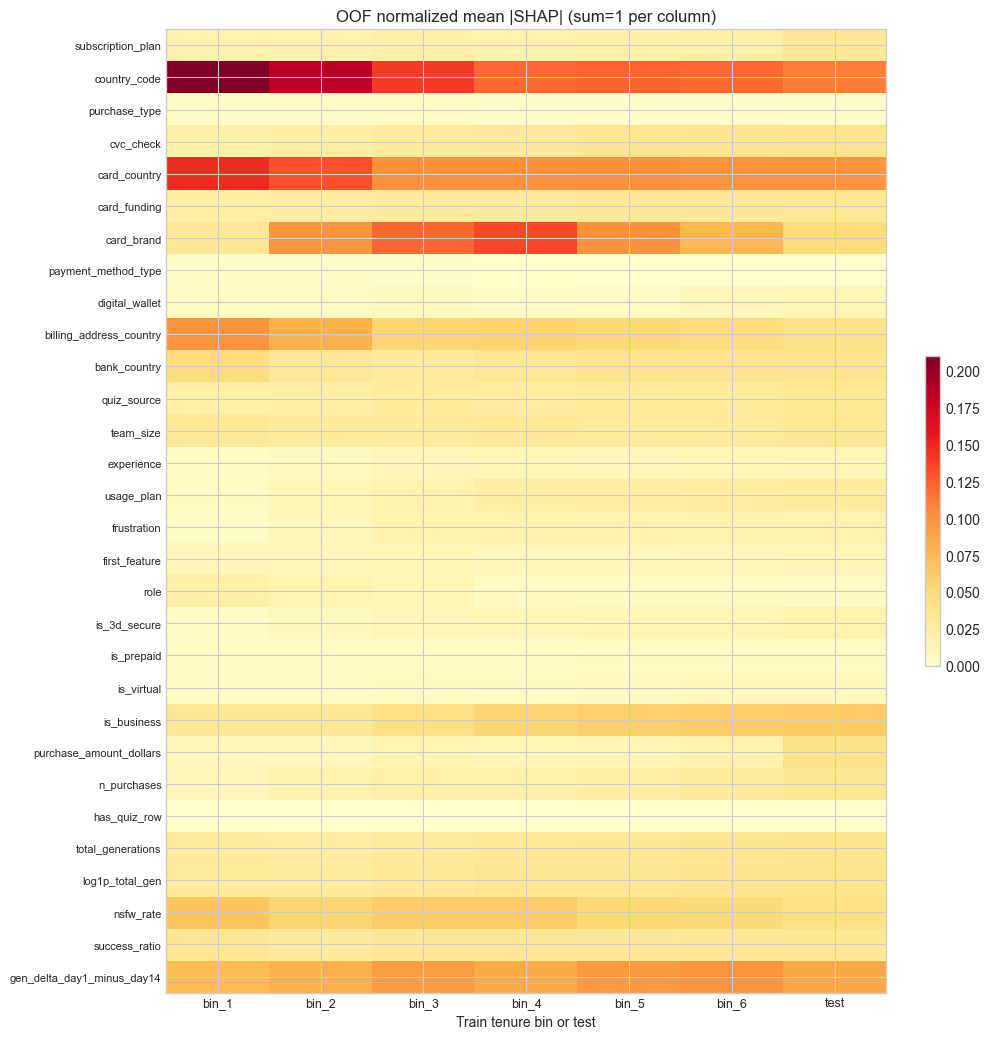

In [48]:
# --- Heatmap: bins 1..6 + test (normalized mean |SHAP|)
cols = [c for c in ma_norm.columns if c.startswith("bin_")] + ["test"]
mat = ma_norm[cols].values
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(FEATURES))))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
ax.set_yticks(np.arange(len(FEATURES)))
ax.set_yticklabels(FEATURES, fontsize=8)
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols, fontsize=9)
ax.set_xlabel("Train tenure bin or test")
ax.set_title("OOF normalized mean |SHAP| (sum=1 per column)")
fig.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()


In [49]:
# --- "Degraded" features: strong early bins, weaker late + test-like penalty
early_cols = [f"bin_{b}" for b in EARLY_BINS if f"bin_{b}" in ma_df.columns]
late_cols = [f"bin_{b}" for b in LATE_BINS if f"bin_{b}" in ma_df.columns]
early = ma_df[early_cols].mean(axis=1)
late = ma_df[late_cols].mean(axis=1)
te = ma_df["test"]
ratio_late = late / (early + 1e-9)
ratio_test = te / (early + 1e-9)
deg = pd.DataFrame(
    {
        "mean_abs_shap_early_bins": early,
        "mean_abs_shap_late_bins": late,
        "mean_abs_shap_test": te,
        "ratio_late_vs_early": ratio_late,
        "ratio_test_vs_early": ratio_test,
    }
)
deg["risk_score"] = early * (1.0 - np.minimum(ratio_late, 1.0)) * (1.0 - np.minimum(ratio_test, 1.0))
deg = deg.sort_values(["mean_abs_shap_early_bins", "ratio_test_vs_early"], ascending=[False, True])
print(
    "Features with relatively high early |SHAP| but lower late & test (top 20 by early importance among those with ratio_test_vs_early < 0.5):"
)
sub = deg[(deg["ratio_test_vs_early"] < 0.5) & (deg["mean_abs_shap_early_bins"] > deg["mean_abs_shap_early_bins"].median())]
display(sub.head(20).round(4))
print("Full table sorted by risk_score:")
display(deg.sort_values("risk_score", ascending=False).head(25).round(4))


Features with relatively high early |SHAP| but lower late & test (top 20 by early importance among those with ratio_test_vs_early < 0.5):


,mean_abs_shap_early_bins,mean_abs_shap_late_bins,mean_abs_shap_test,ratio_late_vs_early,ratio_test_vs_early,risk_score
billing_address_country,8.9464,4.8388,4.0225,0.5409,0.4496,2.2607


Full table sorted by risk_score:


,mean_abs_shap_early_bins,mean_abs_shap_late_bins,mean_abs_shap_test,ratio_late_vs_early,ratio_test_vs_early,risk_score
country_code,19.6773,12.0770,11.0719,0.6138,0.5627,3.3238
billing_address_country,8.9464,4.8388,4.0225,0.5409,0.4496,2.2607
card_country,13.9143,10.0730,9.9940,0.7239,0.7183,1.0823
role,1.8926,0.5097,0.5331,0.2693,0.2817,0.9933
nsfw_rate,5.9615,5.0570,4.2900,0.8483,0.7196,0.2536
payment_method_type,0.1739,0.0324,0.0266,0.1862,0.1532,0.1199
purchase_type,0.3330,0.1925,0.2010,0.5779,0.6035,0.0557
bank_country,3.9850,3.7466,3.7980,0.9402,0.9531,0.0112
card_brand,6.6011,8.7694,4.8835,1.3285,0.7398,0.0000
first_feature,1.0719,1.0752,1.2791,1.0030,1.1933,0.0000


In [50]:
# --- Numeric Pearson correlation with churn per train bin (no test labels)
cor_cols = {b: X_train.loc[bin_ids == b, num_cols].corrwith(y_train.loc[bin_ids == b]) for b in sorted(bin_ids.unique())}
corr_bin = pd.DataFrame(cor_cols)
corr_bin.columns = [f"bin_{c}" for c in corr_bin.columns]
print("Numeric feature correlation with churn_binary by train bin (sample):")
display(corr_bin.T.head(N_BINS))


Numeric feature correlation with churn_binary by train bin (sample):


c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Alarto\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\functi

,is_3d_secure,is_prepaid,is_virtual,is_business,purchase_amount_dollars,n_purchases,has_quiz_row,total_generations,log1p_total_gen,nsfw_rate,success_ratio,gen_delta_day1_minus_day14
bin_1,0.189014,0.212986,0.169614,0.107409,0.124898,0.140474,NaN,0.077590,0.093817,0.217495,-0.123682,0.050519
bin_2,0.164868,0.179869,0.138437,0.094954,0.099715,0.162001,NaN,0.067994,0.088804,0.139474,-0.093743,0.066661
bin_3,0.114006,0.127532,0.115117,0.059061,0.037104,0.098033,NaN,0.111560,0.102249,0.155112,-0.060913,0.081945
bin_4,0.035928,0.044169,0.017992,-0.075389,0.036558,0.012577,NaN,0.101318,0.059961,0.100876,-0.079753,0.070715
bin_5,0.067396,0.036075,0.035915,-0.067778,0.009084,-0.021867,NaN,0.058214,0.003218,0.094058,-0.064146,0.112362
bin_6,0.052143,0.050023,0.033522,-0.102485,-0.017076,-0.042386,NaN,0.011618,-0.011304,0.088297,-0.051960,0.050391


### How to read this

- **Train SHAP is OOF**: each user’s SHAP comes from a model that did **not** train on that user’s label, reducing **in-sample** importance inflation.
- **Test SHAP** is averaged over **K** fold models (each sees ~80% of train); it is **not** OOF in the same sense (no labels on test), but averaging avoids relying on one **full-train** explainer.
- SHAP remains **associational** (not causal): use it to prioritize features for **stability** across time, not as proof of effect.
- **Best-matching `bin_id`** by `sub_days` is a **heuristic** validation slice; combine with **forward-chaining CV** if you need strict temporal generalization.
- If **test** aligns with **late** bins, features that only mattered in **early** OOF bins may **generalize poorly**—consider **regularization** or **time-aware** features.
